In [1]:
!python --version

Python 3.12.10


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import firwin
import requests
from numba import njit

# Практичне завдання №4: Симуляція дельта-сигма перетворювача

### 1-2. НАЛАШТУВАННЯ ТА ЗАВАНТАЖЕННЯ ФАЙЛУ

In [3]:
GITHUB_RAW_URL = "https://raw.githubusercontent.com/Egorkud/digital-signals-2026/main/audio_record.wav"
FILENAME = "audio_record.wav"

OSRx = 64               # Коефіцієнт оверсамплінгу
f_c = 4000              # Частота зрізу фільтра (Гц)
START_SAMPLE = 30500    # Початковий семпл для графіка
END_SAMPLE = 30800      # Кінцевий семпл для графіка

print("Завантаження аудіофайлу з GitHub...")
response = requests.get(GITHUB_RAW_URL)
if response.status_code == 200:
    with open(FILENAME, 'wb') as f:
        f.write(response.content)
    print("Файл успішно завантажено!")
else:
    print(f"Помилка завантаження! Статус-код: {response.status_code}")

# Зчитування аудіо
fs, data = wavfile.read(FILENAME)

# Перетворення в моно, якщо стерео
if data.ndim > 1:
    data = data[:, 0]

# Нормалізація амплітуди до діапазону [-1.0, 1.0]
data_float = data.astype(float)
max_val = np.max(np.abs(data_float))
if max_val > 0:
    data_float = data_float / max_val

# Для оптимізації симуляції беремо лише першу секунду аудіо
data_float = data_float[:fs]

Завантаження аудіофайлу з GitHub...
Файл успішно завантажено!


## Оверсамплінг та Дельта-Сигма Модуляція
Використовуємо `numba.njit` для JIT-компіляції авторського модулятора. Це дозволяє циклу працювати зі швидкістю C-коду, що критично для масивів з мільйонами елементів після оверсамплінгу.

### 3. ОВЕРСАМПЛІНГ ТА ΔΣ МОДУЛЯТОР

In [4]:
print(f"Оверсамплінг у {OSRx} разів (zero-order hold)...")
data_osr = np.repeat(data_float, OSRx)

@njit
def run_delta_sigma(input_data: np.ndarray) -> np.ndarray:
    """Авторська реалізація 1-бітного ΔΣ модулятора 1-го порядку."""
    n = len(input_data)
    y_1bit = np.zeros(n, dtype=np.float32)
    integral = 0.0
    y_out = 0.0

    for i in range(n):
        error = input_data[i] - y_out
        integral += error
        # 1-бітний квантувач
        y_out = 1.0 if integral >= 0 else -1.0
        y_1bit[i] = y_out

    return y_1bit

print("Генерація 1-бітного потоку...")
y_1bit_stream = run_delta_sigma(data_osr)

Оверсамплінг у 64 разів (zero-order hold)...
Генерація 1-бітного потоку...


## Фільтрація Згорткою та Децимація
Замість рекурсивного IIR фільтра (як `lfilter`), за умовою завдання застосовується **операція згортки** (`np.convolve`). Для цього ми спочатку генеруємо коефіцієнти FIR-фільтра за допомогою `scipy.signal.firwin`.

### 4. ФІЛЬТРАЦІЯ З ДОПОМОГОЮ ЗГОРТКИ

In [5]:
print(f"Розрахунок FIR-фільтра та виконання згортки (f_c = {f_c} Гц)...")
fs_osr = fs * OSRx

# Створення коефіцієнтів FIR-фільтра (чим більше numtaps, тим краще фільтрує, але довше рахує)
# 101 коефіцієнт є хорошим компромісом для Colab
num_taps = 101
fir_coeff = firwin(num_taps, cutoff=f_c, fs=fs_osr, window='hamming')

# Виконання математичної згортки (convolution)
# mode='same' гарантує, що довжина вихідного масиву дорівнюватиме вхідному
filtered_signal = np.convolve(y_1bit_stream, fir_coeff, mode='same')

Розрахунок FIR-фільтра та виконання згортки (f_c = 4000 Гц)...


### 5. ДЕЦИМАЦІЯ СИГНАЛУ

In [6]:
print("Децимація відфільтрованого сигналу...")
decimated_signal = filtered_signal[::OSRx]

Децимація відфільтрованого сигналу...


## 6. Візуалізація результатів
Побудова вхідного, 1-бітного та децимованого сигналів на одному графіку для заданої ділянки семплів.

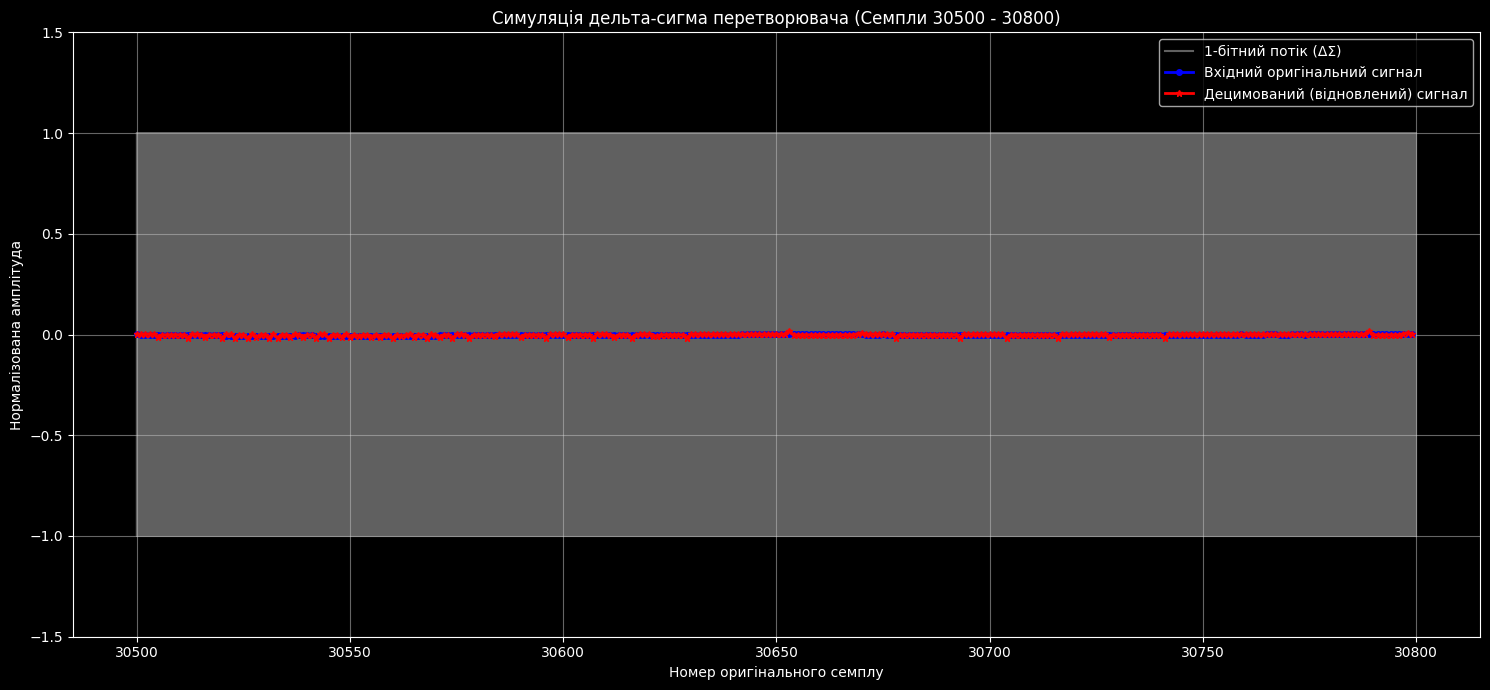

Симуляція успішно завершена!


In [7]:
# Створення масивів індексів для правильного масштабування осі X
x_base = np.arange(START_SAMPLE, END_SAMPLE)
start_osr = START_SAMPLE * OSRx
end_osr = END_SAMPLE * OSRx
x_osr = np.arange(start_osr, end_osr) / OSRx

plt.figure(figsize=(15, 7))

# Відображення 1-бітного потоку (висока частота)
plt.step(x_osr, y_1bit_stream[start_osr:end_osr], color='silver', alpha=0.5,
         where='post', label='1-бітний потік (ΔΣ)')

# Відображення оригінального сигналу
plt.plot(x_base, data_float[START_SAMPLE:END_SAMPLE], 'b-o',
         linewidth=2, markersize=4, label='Вхідний оригінальний сигнал')

# Відображення децимованого сигналу після згортки
plt.plot(x_base, decimated_signal[START_SAMPLE:END_SAMPLE], 'r-*',
         linewidth=2, markersize=5, label='Децимований (відновлений) сигнал')

plt.title(f'Симуляція дельта-сигма перетворювача (Семпли {START_SAMPLE} - {END_SAMPLE})')
plt.xlabel('Номер оригінального семплу')
plt.ylabel('Нормалізована амплітуда')
plt.ylim(-1.5, 1.5)
plt.grid(True, alpha=0.4)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()
print("Симуляція успішно завершена!")